# Sesión 6: arquitecturas multiagente, MCP y skills

En esta sesión vamos a continuar directamente desde el final de la sesión anterior. Ya vimos que un agente puede usar herramientas, hacer handoff a otro agente y consultar agentes especializados como herramientas. Vamos a ordenar esas piezas como decisiones de arquitectura: cuándo conviene transferir la conversación, cuándo conviene coordinar especialistas, cuándo separar planificación y ejecución, cuándo externalizar capacidades con MCP y cuándo cargar conocimiento especializado mediante skills.

El hilo conductor será deliberadamente progresivo. Primero retomaremos los handoffs, porque son la forma más directa de pasar control conversacional a un especialista. Después volveremos a los subagentes, ampliando el patrón hasta arquitecturas jerárquicas donde un agente principal puede coordinar a otros agentes y alguno de esos agentes puede coordinar a su vez a otros especialistas. A continuación estudiaremos planner/executor, que separa la definición del trabajo de su ejecución. Luego introduciremos MCP como protocolo para sacar herramientas y contexto fuera del notebook. Por último, cerraremos con skills como mecanismo para empaquetar instrucciones, referencias, scripts y assets reutilizables.

La idea no es acumular patrones, sino aprender a reconocer dónde vive el control. En un handoff, el control pasa al agente receptor. En subagentes, el supervisor conserva la síntesis. En planner/executor, una fase decide el trabajo y otra lo realiza. En MCP, el agente consume capacidades publicadas por servidores externos. En skills, el agente carga método y contexto especializado desde archivos del proyecto.


## Objetivos de aprendizaje

Al terminar la sesión deberías poder leer una petición de usuario y decidir qué forma de coordinación conviene antes de escribir código. Si el problema consiste en derivar una conversación a un área responsable, pensaremos en handoffs. Si la respuesta requiere integrar evidencias de varios especialistas, pensaremos en subagentes. Si el trabajo es amplio y conviene auditar pasos antes de ejecutarlos, pensaremos en planner/executor. Si las herramientas viven fuera del proceso de Python o queremos compartirlas entre clientes, pensaremos en MCP. Si lo que necesitamos es empaquetar instrucciones y recursos especializados, pensaremos en skills.

También vamos a diferenciar responsabilidades que a menudo se confunden. Un subagente no es simplemente una herramienta con otro nombre: es un agente con instrucciones propias, que puede tener herramientas propias y cuyo resultado parcial vuelve a un supervisor. Un handoff no es una consulta: es una transferencia de agente activo. Un servidor MCP no es una skill: publica herramientas, recursos o prompts mediante un protocolo. Una skill no publica herramientas por red: organiza instrucciones, referencias, scripts y assets para que el agente cargue contexto especializado bajo demanda.

El notebook mantiene el dominio autocontenido de operaciones internas: políticas corporativas, inventario, métricas regionales y solicitudes de soporte. Esto nos permite comparar patrones sin depender de una aplicación externa, pero también añadiremos un servidor MCP local para ver cómo sería sacar parte de esas capacidades fuera del notebook.


## Preguntas de diseño antes de elegir patrón

La primera pregunta es quién debe continuar la conversación. Si queremos que el usuario pase a hablar con RRHH, Finanzas o Seguridad, el patrón natural es handoff. Si no queremos cambiar la voz final, sino consultar especialistas internamente, el patrón natural es subagentes. Esta distinción es pequeña en código, pero enorme en producto: cambia qué agente recibe el siguiente turno, quién pide aclaraciones y dónde se conserva el estado conversacional.

La segunda pregunta es si necesitamos un plan explícito. Un agente supervisor puede decidir sobre la marcha qué especialistas consultar, pero a veces queremos separar "qué hay que hacer" de "hacerlo". Planner/executor introduce una representación intermedia que podemos inspeccionar, guardar, validar o someter a revisión humana antes de ejecutar herramientas.

La tercera pregunta es dónde viven las capacidades. Si la herramienta está dentro del notebook, una función decorada con `@function_tool` basta. Si queremos que esa capacidad pueda ser consumida por distintos agentes, clientes o aplicaciones, MCP permite publicarla como servidor. Si la capacidad no es una herramienta sino un método de trabajo con documentación, scripts y plantillas, una skill encaja mejor.

La cuarta pregunta es cómo vamos a depurar. Cada patrón tiene fallos distintos: un handoff puede transferir al agente equivocado; un supervisor puede ignorar a un especialista necesario; un planner puede omitir un paso crítico; un servidor MCP puede exponer demasiadas herramientas; una skill puede cargar contexto innecesario. Por eso cada sección incluye trazas, inspección o evaluación ligera.


## 0. Preparación del entorno

Usaremos el SDK de agentes de OpenAI para expresar los patrones de forma compacta: agentes con herramientas propias, agentes expuestos como herramientas, handoffs, salidas estructuradas y trazas. Aquí usamos este SDK porque ya encaja con la progresión de sesiones anteriores y permite que el notebook sea práctico.

El notebook espera una variable `OPENAI_API_KEY`. Puedes cargarla desde un archivo `.env` situado junto al notebook o introducirla por consola cuando se pida. Los modelos se configuran mediante variables de entorno para facilitar cambios sin tocar todas las celdas. Por defecto usamos un modelo pequeño para las demostraciones, ya que ejecutaremos varias llamadas y lo importante es comparar patrones, no maximizar calidad de redacción.


In [ ]:
# Si estás en un entorno limpio, descomenta esta celda.
# Después de instalar, puede ser necesario reiniciar el kernel.
# %pip install -q -U openai openai-agents mcp python-dotenv pandas pydantic graphviz tiktoken ipykernel


### 0.1. Imports y configuración común

Esta celda concentra imports, rutas y configuración. El resto del notebook usa `GENERATION_MODEL` para agentes que producen respuestas y `FAST_MODEL` para tareas de clasificación o selección. Inicialmente pueden apuntar al mismo modelo. En sistemas reales es habitual separar estos papeles: un modelo rápido puede bastar para enrutar o seleccionar skills, mientras que un modelo más capaz puede reservarse para síntesis final o decisiones complejas.


In [ ]:
import asyncio
import sys
import getpass
import os
import time
from pathlib import Path
from typing import Any, Literal

import pandas as pd
import tiktoken
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from openai import OpenAI

from agents import Agent, HostedMCPTool, Runner
from agents.run import RunConfig
from agents.sandbox import SandboxAgent, SandboxRunConfig
from agents.mcp import MCPServerStdio, MCPServerStreamableHttp, create_static_tool_filter
from agents.sandbox.capabilities import Shell, Skills
from agents.sandbox.entries import LocalDir
from agents.sandbox.sandboxes.unix_local import UnixLocalSandboxClient

os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

ModuleNotFoundError: No module named 'docker'

In [ ]:
def find_session_dir() -> Path:
    current = Path.cwd()
    if (current / "sesion_06.ipynb").exists():
        return current
    if (current / "sesion_06" / "sesion_06.ipynb").exists():
        return current / "sesion_06"
    return current


SESSION_DIR = find_session_dir()
load_dotenv(SESSION_DIR / ".env")

if not os.getenv("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

GENERATION_MODEL = os.getenv("OPENAI_GENERATION_MODEL", "gpt-4.1-mini")
FAST_MODEL = os.getenv("OPENAI_FAST_MODEL", os.getenv("OPENAI_EVALUATION_MODEL", GENERATION_MODEL))

print("Directorio de sesión:", SESSION_DIR)
print("Modelo generativo:", GENERATION_MODEL)
print("Modelo rápido:", FAST_MODEL)


Directorio de sesión: /Users/aruizart/Documents/01. Trabajo/02. Pontia/01. Máster IA/01. Large Language Models/sesion_06
Modelo generativo: gpt-4.1-mini
Modelo rápido: gpt-4.1-mini


## 1. Antes de hablar de agentes: el dominio y sus contratos

Una arquitectura multiagente no compensa herramientas pobres. Si una herramienta acepta argumentos ambiguos, devuelve texto impredecible o mezcla responsabilidades, el problema se amplifica al añadir agentes. Por eso seguimos usando un dominio mínimo con contratos deterministas antes de hablar de coordinación entre agentes.

Este dominio continúa la línea de la sesión anterior. Allí ya habíamos usado tres capacidades básicas: búsqueda en documentación interna, consulta de inventario y resumen de métricas comerciales. En esta sesión las recuperamos desde `operations_support.py` para no gastar tiempo de clase volviendo a implementar lo mismo. La versión de esta sesión mantiene la misma idea, pero adapta nombres y campos al caso multiagente: políticas internas, inventario de hardware, métricas por región y un cálculo explícito del circuito de aprobación.

El punto importante no está en el código de esas funciones, sino en la frontera que representan. Da igual si luego usamos handoffs, subagentes, planner/executor, MCP o skills: todas esas arquitecturas deberían apoyarse en capacidades de negocio probables, inspeccionables y reutilizables. Si mañana cambiamos la orquestación, `search_policy_documents`, `get_inventory_status`, `summarize_regions` y `approval_path_for_amount` deberían seguir teniendo sentido fuera del agente.


In [88]:
import operations_support as ops
from operations_support import (
    approval_path_for_amount,
    check_inventory,
    estimate_approval_path,
    get_inventory_status,
    search_internal_policy,
    search_policy_documents,
    summarize_region_metrics,
    summarize_regions,
    to_json,
)


In [89]:
print("SEARCH POLICY DOCUMENTS:")
print(to_json(search_policy_documents("aprobación compra hardware 1200 EUR", k=2)))

print("\n\nGET INVENTORY STATUS:")
print(to_json(get_inventory_status("monitor-27", requested_units=12)))

print("\n\nAPPROVAL PATH FOR AMOUNT:")
print(to_json(approval_path_for_amount(12 * 219.0)))


SEARCH POLICY DOCUMENTS:
[
  {
    "source": "finanzas_compras.md",
    "area": "Finanzas",
    "title": "Compras y aprobaciones de gasto",
    "text": "Las compras inferiores a 500 EUR pueden aprobarse por el manager directo. Entre 500 y 2.000 EUR se requiere aprobación del responsable de área y validación de Finanzas. Por encima de 2.000 EUR se requiere aprobación de Dirección y orden de compra formal. Toda compra de hardware debe incluir centro de coste, proveedor recomendado y justificación de necesidad.",
    "score": 4
  },
  {
    "source": "it_hardware.md",
    "area": "IT",
    "title": "Asignación de hardware corporativo",
    "text": "El hardware corporativo se asigna priorizando nuevas incorporaciones, equipos comerciales y soporte crítico. Monitores, docks y portátiles deben revisarse contra inventario antes de confirmar plazos. Si el stock disponible no cubre la solicitud completa, IT debe proponer entrega parcial o compra adicional.",
    "score": 2
  }
]


GET INVENTORY

## 2. Herramientas expuestas al modelo

Las herramientas ya vienen importadas desde `operations_support.py`. Internamente son funciones decoradas con `@function_tool`, igual que en la sesión anterior, pero aquí no necesitamos volver a escribir sus cuerpos. En clase nos interesa más observar cómo esas mismas herramientas se combinan de formas distintas según la arquitectura.

Recuerda que un buen criterio es que cada herramienta responda a una pregunta operativa clara. `search_internal_policy` responde "qué norma interna aplica". `check_inventory` responde "qué disponibilidad y coste tiene este producto". `summarize_region_metrics` responde "qué contexto regional tenemos". `estimate_approval_path` responde "qué aprobación exige este importe". No mezclamos todas esas tareas en una única herramienta universal porque perderíamos trazabilidad.


In [90]:
BUSINESS_TOOLS = [
    search_internal_policy,
    check_inventory,
    summarize_region_metrics,
    estimate_approval_path,
]

pd.DataFrame(
    {
        "tool": getattr(tool, "name", repr(tool)),
        "description": getattr(tool, "description", ""),
    }
    for tool in BUSINESS_TOOLS
)


,tool,description
0,search_internal_policy,Busca políticas internas relevantes.
1,check_inventory,"Consulta disponibilidad, precio, almacén y pla..."
2,summarize_region_metrics,"Resume revenue, coste, margen, pipeline y conv..."
3,estimate_approval_path,Estima el circuito de aprobación necesario par...


## 3. Instrumentación mínima para comparar patrones

En un sistema multiagente no basta con leer la respuesta final. Dos arquitecturas pueden producir un texto parecido y haber seguido recorridos completamente distintos. Una puede haber consultado inventario y política; otra puede haber respondido desde conocimiento general; otra puede haber derivado al agente equivocado y aun así sonar convincente.

La función `describe_run_items` resume los elementos generados por el SDK durante una ejecución. No sustituye a una plataforma de observabilidad, pero sí permite ver qué agente actuó, qué herramientas se llamaron, con qué argumentos y qué salida devolvieron. Durante la sesión, esta tabla permite comprobar si la ejecución coincide con el patrón diseñado.

También añadimos una función de estimación de tokens basada en `tiktoken`. No intenta reconstruir la facturación exacta de una llamada completa, porque en una ejecución real también cuentan mensajes, instrucciones del sistema, schemas de herramientas y otros metadatos que gestiona el SDK. Aun así, sí nos permite comparar con bastante más criterio el tamaño relativo de distintos contextos: instrucciones cargadas desde el inicio, documentación de una skill, plan estructurado, evidencias intermedias o texto que viaja entre agentes.


In [91]:
def compact(value: Any, *, limit: int = 360) -> str:
    if value is None:
        return ""
    text = value if isinstance(value, str) else repr(value)
    text = " ".join(text.split())
    return text if len(text) <= limit else f"{text[:limit]}..."


def raw_field(raw_item: Any, field: str, default: Any = "") -> Any:
    if isinstance(raw_item, dict):
        return raw_item.get(field, default)
    return getattr(raw_item, field, default)


def message_text(raw_item: Any) -> str:
    content = raw_field(raw_item, "content", []) or []
    pieces = []
    for part in content:
        text = raw_field(part, "text", None)
        refusal = raw_field(part, "refusal", None)
        if text:
            pieces.append(text)
        elif refusal:
            pieces.append(refusal)
    return "\n".join(pieces)


def item_output_text(item: Any) -> str:
    if hasattr(item, "output"):
        return compact(getattr(item, "output"))

    raw_item = getattr(item, "raw_item", None)
    raw_output = raw_field(raw_item, "output", None)
    if raw_output not in (None, ""):
        return compact(raw_output)

    if raw_field(raw_item, "type", "") == "message":
        return compact(message_text(raw_item))

    if type(item).__name__ == "MCPListToolsItem":
        return compact(raw_field(raw_item, "tools", ""))

    return ""


def describe_run_items(run_result: Any) -> pd.DataFrame:
    rows = []
    call_names_by_id: dict[str, str] = {}

    for index, item in enumerate(run_result.new_items, start=1):
        raw_item = getattr(item, "raw_item", None)
        agent = getattr(item, "agent", None)
        call_id = raw_field(raw_item, "call_id", raw_field(raw_item, "id", ""))
        name = raw_field(raw_item, "name", "")

        if name and call_id:
            call_names_by_id[str(call_id)] = str(name)
        elif call_id:
            name = call_names_by_id.get(str(call_id), "")

        rows.append(
            {
                "step": index,
                "item_type": type(item).__name__,
                "agent": getattr(agent, "name", ""),
                "raw_type": raw_field(raw_item, "type", ""),
                "name": name,
                "arguments": compact(raw_field(raw_item, "arguments", "")),
                "output": item_output_text(item),
            }
        )
    return pd.DataFrame(rows)


def used_tool_like_step(run_result: Any) -> bool:
    return any("tool" in type(item).__name__.lower() for item in run_result.new_items)


def print_agent_result(label: str, run_result: Any) -> None:
    print(f"[{label}]")
    print("Último agente:", run_result.last_agent.name)
    print("Salida final:")
    print(run_result.final_output)


def encoding_for_model_name(model_name: str) -> tiktoken.Encoding:
    try:
        return tiktoken.encoding_for_model(model_name)
    except KeyError:
        return tiktoken.get_encoding("o200k_base")


def rough_token_estimate(text: str, *, model_name: str | None = None) -> int:
    """Cuenta tokens de texto con tiktoken.

    La cifra corresponde al texto pasado a la función. Una llamada completa al modelo
    puede incluir tokens adicionales por mensajes, instrucciones, herramientas y schemas.
    """
    if not isinstance(text, str):
        text = str(text)
    if not text:
        return 0

    encoding = encoding_for_model_name(model_name or GENERATION_MODEL)
    return len(encoding.encode(text))


## 4. Punto de partida: un agente único con herramientas

Antes de añadir arquitecturas multiagente, conviene construir el punto de partida más simple. Un agente único con herramientas puede resolver muchas tareas con menos llamadas, menos estado y menos superficie de fallo. Esta suele ser la recomendación práctica más sensata: empezar con un agente simple y buenas herramientas, y escalar solo cuando aparezcan límites claros.

El agente monolítico que definimos a continuación conoce todas las herramientas. Eso le permite resolver preguntas mixtas, pero también introduce una tensión: sus instrucciones deben cubrir Finanzas, IT, RRHH, Seguridad y Operaciones. En una demo pequeña funciona. En una organización real, esta instrucción crecería, varios equipos querrían editarla y cada nueva capacidad competiría por espacio de contexto.

El objetivo de ejecutar este agente no es concluir que está mal. De hecho, muchas veces será suficiente. Lo ejecutamos para tener una línea base contra la que comparar los patrones posteriores. Si una arquitectura multiagente no aporta mejor control, mejor aislamiento de contexto, paralelización o mantenibilidad, probablemente no merezca la complejidad añadida.


In [92]:
monolithic_agent = Agent(
    name="AgenteUnicoOperaciones",
    model=GENERATION_MODEL,
    instructions=(
        "Eres un asistente interno de operaciones. Puedes responder sobre Finanzas, IT, RRHH, Seguridad y métricas regionales. "
        "Usa herramientas cuando la respuesta dependa de políticas, inventario, aprobaciones o métricas. "
        "Explica la recomendación con evidencia concreta y no inventes datos que no estén disponibles."
    ),
    tools=[
        search_internal_policy,
        check_inventory,
        summarize_region_metrics,
        estimate_approval_path,
    ],
)


In [93]:
baseline_question = (
    "Necesito comprar 12 monitor-27 para EMEA. "
    "Dime si hay stock, qué aprobación necesito y si tiene sentido priorizarlo."
)

baseline_result = await Runner.run(monolithic_agent, baseline_question)
print_agent_result("Agente único", baseline_result)
describe_run_items(baseline_result)


[Agente único]
Último agente: AgenteUnicoOperaciones
Salida final:
Para la compra de 12 monitores de 27 pulgadas para EMEA, te informo lo siguiente:

- Actualmente hay stock disponible para 8 unidades en el almacén de Madrid, con un plazo de entrega de 2 días.
- Faltan 4 unidades para completar el pedido, por lo que estas deberán ser solicitadas al proveedor.
- El precio por unidad es de 219 EUR, y el importe total estimado para las 12 unidades es de 2628 EUR.
- Para aprobar esta compra, el manager directo puede autorizar la adquisición, dado que el importe a aprobar es de 12 EUR (posiblemente un error de sistema en la interpretación del importe, pero según política se requiere aprobación del manager directo).

Respecto a si tiene sentido priorizar la compra, dado que solo faltan 4 unidades para completar el pedido y el resto está en stock con entrega rápida, puede ser razonable hacer la compra para no retrasar la dotación de los equipos. Debería considerarse la urgencia del uso de est

,step,item_type,agent,raw_type,name,arguments,output
0,1,ToolCallItem,AgenteUnicoOperaciones,function_call,check_inventory,"{""product_id"":""monitor-27"",""requested_units"":12}",
1,2,ToolCallItem,AgenteUnicoOperaciones,function_call,estimate_approval_path,"{""amount_eur"":12}",
2,3,ToolCallOutputItem,AgenteUnicoOperaciones,function_call_output,check_inventory,,"{ ""product_id"": ""monitor-27"", ""name"": ""Monitor..."
3,4,ToolCallOutputItem,AgenteUnicoOperaciones,function_call_output,estimate_approval_path,,"{ ""amount_eur"": 12.0, ""approval_path"": ""manage..."
4,5,MessageOutputItem,AgenteUnicoOperaciones,message,,,Para la compra de 12 monitores de 27 pulgadas ...


Después de ejecutar la línea base, fíjate en dos señales. La primera es si el agente usa herramientas o responde de memoria. La segunda es cuántas responsabilidades ha tenido que coordinar dentro de una sola instrucción. Mientras el dominio es pequeño, esto puede ser perfectamente aceptable. El problema aparece cuando la instrucción crece hasta convertirse en una mezcla de manual de Finanzas, guía de IT, política de Seguridad y playbook comercial.

El resto del notebook explora cuatro maneras de aliviar esa presión. No son una escalera obligatoria ni opciones excluyentes. En sistemas reales se combinan: un agente conversacional puede usar skills, llamar a subagentes y hacer handoff a soporte humano en ciertas condiciones. Lo importante es entender qué problema resuelve cada patrón.


## Mapa mental de los patrones

Antes de implementar, conviene fijar la diferencia entre los patrones que veremos. En handoffs, el agente de entrada decide transferir la conversación y el especialista receptor se convierte en el agente activo. En subagentes, el agente principal conserva el control y consulta especialistas como capacidades internas. En una jerarquía, esa idea se repite por niveles: un director puede consultar a un coordinador, y ese coordinador a su vez consultar a especialistas más pequeños. En planner/executor, la frontera no está entre departamentos, sino entre planificar y ejecutar. En MCP, la frontera está entre el agente y un servidor externo que publica herramientas o recursos. En skills, la frontera está entre el prompt principal y el conocimiento especializado que se carga desde archivos.

Esta lectura ayuda a no convertir todo en una red indistinta de agentes. Si queremos estado conversacional por etapas, handoff. Si queremos síntesis centralizada, subagentes. Si queremos trazabilidad previa a la acción, planner/executor. Si queremos interoperabilidad de herramientas, MCP. Si queremos empaquetar método y recursos, skills.


> **NOTA:** Los grafos de Graphviz que se verán en la sesión se definen a continuación una sola vez para no repetir código. A partir de aquí, cada arquitectura mostrará su propio diagrama en el momento en que se explica.


In [94]:
ARCHITECTURE_DOTS = {
    "handoffs": """
        digraph Handoffs {
            graph [rankdir=LR, bgcolor="white"];
            node [shape=box, style="rounded,filled", color="#334155", fillcolor="#f8fafc", fontname="Helvetica"];
            edge [color="#475569", fontname="Helvetica"];

            Usuario [shape=oval, fillcolor="#ecfeff"];
            EntradaOperaciones [fillcolor="#dbeafe"];
            RRHHOnboarding [fillcolor="#fef3c7"];
            FinanzasCompras [fillcolor="#dcfce7"];
            SeguridadAccesos [fillcolor="#fee2e2"];

            Usuario -> EntradaOperaciones [label="solicitud"];
            EntradaOperaciones -> RRHHOnboarding [label="handoff onboarding"];
            EntradaOperaciones -> FinanzasCompras [label="handoff compras"];
            EntradaOperaciones -> SeguridadAccesos [label="handoff seguridad"];
            RRHHOnboarding -> Usuario [label="continúa conversación"];
            FinanzasCompras -> Usuario [label="continúa conversación"];
            SeguridadAccesos -> Usuario [label="continúa conversación"];
        }
    """,
    "subagentes": """
        digraph Subagentes {
            graph [rankdir=LR, bgcolor="white"];
            node [shape=box, style="rounded,filled", color="#334155", fillcolor="#f8fafc", fontname="Helvetica"];
            edge [color="#475569", fontname="Helvetica"];

            Usuario [shape=oval, fillcolor="#ecfeff"];
            SupervisorOperaciones [fillcolor="#dbeafe"];
            SubagentePoliticas [fillcolor="#dcfce7"];
            SubagenteInventario [fillcolor="#fef3c7"];
            SubagenteMetricas [fillcolor="#fae8ff"];

            Usuario -> SupervisorOperaciones [label="petición compuesta"];
            SupervisorOperaciones -> SubagentePoliticas [label="consulta"];
            SupervisorOperaciones -> SubagenteInventario [label="consulta"];
            SupervisorOperaciones -> SubagenteMetricas [label="consulta"];
            SubagentePoliticas -> SupervisorOperaciones [label="evidencia"];
            SubagenteInventario -> SupervisorOperaciones [label="evidencia"];
            SubagenteMetricas -> SupervisorOperaciones [label="evidencia"];
            SupervisorOperaciones -> Usuario [label="síntesis final"];
        }
    """,
    "jerarquia": """
        digraph Jerarquia {
            graph [rankdir=LR, bgcolor="white"];
            node [shape=box, style="rounded,filled", color="#334155", fillcolor="#f8fafc", fontname="Helvetica"];
            edge [color="#475569", fontname="Helvetica"];

            Usuario [shape=oval, fillcolor="#ecfeff"];
            DirectorOperaciones [fillcolor="#dbeafe"];
            CoordinadorHardware [fillcolor="#e0e7ff"];
            SubagenteSeguridad [fillcolor="#fee2e2"];
            Politicas [fillcolor="#dcfce7"];
            Inventario [fillcolor="#fef3c7"];
            Metricas [fillcolor="#fae8ff"];

            Usuario -> DirectorOperaciones [label="recomendación ejecutiva"];
            DirectorOperaciones -> CoordinadorHardware [label="delegación"];
            DirectorOperaciones -> SubagenteSeguridad [label="revisión riesgo"];
            CoordinadorHardware -> Politicas [label="consulta"];
            CoordinadorHardware -> Inventario [label="consulta"];
            CoordinadorHardware -> Metricas [label="consulta"];
            Politicas -> CoordinadorHardware;
            Inventario -> CoordinadorHardware;
            Metricas -> CoordinadorHardware;
            CoordinadorHardware -> DirectorOperaciones [label="recomendación parcial"];
            SubagenteSeguridad -> DirectorOperaciones [label="riesgos"];
            DirectorOperaciones -> Usuario [label="síntesis ejecutiva"];
        }
    """,
    "planner_executor": """
        digraph PlannerExecutor {
            graph [rankdir=LR, bgcolor="white"];
            node [shape=box, style="rounded,filled", color="#334155", fillcolor="#f8fafc", fontname="Helvetica"];
            edge [color="#475569", fontname="Helvetica"];

            Usuario [shape=oval, fillcolor="#ecfeff"];
            Planner [label="PlanificadorOperativo", fillcolor="#dbeafe"];
            Plan [shape=note, fillcolor="#fef9c3", label="ExecutionPlan"];
            Revision [shape=diamond, fillcolor="#fee2e2", label="Confirmación humana"];
            Executor [label="EjecutorOperativo", fillcolor="#e0e7ff"];
            Herramientas [shape=component, fillcolor="#dcfce7", label="policy / inventory / metrics"];

            Usuario -> Planner [label="objetivo amplio"];
            Planner -> Plan [label="propone plan"];
            Plan -> Revision [label="presenta al usuario"];
            Revision -> Planner [label="modificar", style=dashed];
            Revision -> Executor [label="aprobar"];
            Executor -> Herramientas [label="ejecuta pasos"];
            Herramientas -> Executor [label="evidencia"];
            Executor -> Usuario [label="respuesta final"];
        }
    """,
    "mcp": """
        digraph MCP {
            graph [rankdir=LR, bgcolor="white"];
            node [shape=box, style="rounded,filled", color="#334155", fillcolor="#f8fafc", fontname="Helvetica"];
            edge [color="#475569", fontname="Helvetica"];

            Usuario [shape=oval, fillcolor="#ecfeff"];
            AgenteConMCP [fillcolor="#dbeafe"];
            MCPClient [label="MCP client\n(Agents SDK)", fillcolor="#e0e7ff"];
            MCPServer [label="operations_mcp_server.py\nFastMCP stdio", fillcolor="#fef3c7"];
            ToolPolicy [label="tool: search_policy", fillcolor="#dcfce7"];
            ToolInventory [label="tool: inventory_status", fillcolor="#dcfce7"];
            ResourcePolicy [label="resource: policy://{area}", fillcolor="#fae8ff"];

            Usuario -> AgenteConMCP [label="pregunta"];
            AgenteConMCP -> MCPClient [label="herramientas MCP"];
            MCPClient -> MCPServer [label="stdio"];
            MCPServer -> ToolPolicy;
            MCPServer -> ToolInventory;
            MCPServer -> ResourcePolicy;
            ToolPolicy -> MCPServer;
            ToolInventory -> MCPServer;
            MCPServer -> MCPClient [label="resultados"];
            MCPClient -> AgenteConMCP;
            AgenteConMCP -> Usuario [label="respuesta"];
        }
    """,
    "skills": """
        digraph Skills {
            graph [rankdir=LR, bgcolor="white"];
            node [shape=box, style="rounded,filled", color="#334155", fillcolor="#f8fafc", fontname="Helvetica"];
            edge [color="#475569", fontname="Helvetica"];

            Usuario [shape=oval, fillcolor="#ecfeff"];
            SandboxAgent [label="AgenteConSkillsDesdeArchivos", fillcolor="#dbeafe"];
            SkillsCapability [label="Skills(from_=LocalDir(...))", fillcolor="#e0e7ff"];
            Workspace [label=".agents/", shape=folder, fillcolor="#fef3c7"];
            SkillMD [label="SKILL.md", shape=note, fillcolor="#dcfce7"];
            References [label="references/", shape=folder, fillcolor="#fae8ff"];
            Scripts [label="scripts/", shape=folder, fillcolor="#fae8ff"];
            Assets [label="assets/", shape=folder, fillcolor="#fae8ff"];
            Tools [label="herramientas de negocio", shape=component, fillcolor="#dcfce7"];

            Usuario -> SandboxAgent [label="solicitud"];
            SandboxAgent -> SkillsCapability [label="índice de skills"];
            SkillsCapability -> Workspace [label="monta carpetas"];
            Workspace -> SkillMD;
            Workspace -> References;
            Workspace -> Scripts;
            Workspace -> Assets;
            SandboxAgent -> SkillMD [label="lee bajo demanda"];
            SandboxAgent -> References [label="consulta si hace falta"];
            SandboxAgent -> Scripts [label="ejecuta si hace falta"];
            SandboxAgent -> Tools [label="obtiene evidencia"];
            SandboxAgent -> Usuario [label="respuesta"];
        }
    """,
}


def render_architecture_diagram(name: str):
    dot = ARCHITECTURE_DOTS[name]
    try:
        from graphviz import Source

        return Source(dot)
    except Exception:
        print(dot)
        return dot


## 5. Handoffs: transiciones de estado y agente activo

En un handoff, el agente activo cambia. No estamos consultando a un especialista para que devuelva una pieza de evidencia al supervisor; estamos transfiriendo la conversación a otro agente. Este patrón es especialmente útil para flujos secuenciales, atención al cliente y experiencias conversacionales en las que ciertas capacidades se desbloquean después de cumplir precondiciones.

La diferencia con un clasificador simple puede parecer sutil. Un clasificador decide una categoría. Un handoff cambia quién sigue hablando con el usuario. Si una solicitud entra por una mesa general y se transfiere a RRHH, el especialista de RRHH puede continuar preguntando por fecha de incorporación, manager o rol. El estado conversacional importa porque la siguiente respuesta del usuario debe interpretarse dentro del contexto del especialista activo.

Este patrón encaja cuando queremos que cada dominio tenga su propio tono, sus propias herramientas y su propio flujo de preguntas. También encaja cuando una conversación debe avanzar por etapas: primero identificar el caso, luego pedir datos obligatorios, después validar condiciones y finalmente proponer una acción. Su coste es que requiere gestionar estado con cuidado. Si el sistema olvida qué agente está activo, la conversación puede volver al triaje innecesariamente o saltar de dominio sin control.


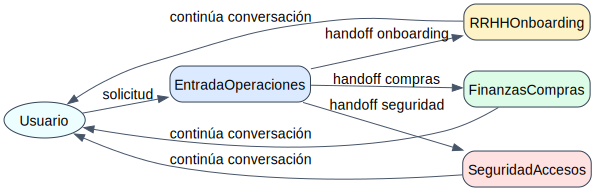

In [95]:
render_architecture_diagram("handoffs")

In [96]:
hr_handoff_agent = Agent(
    name="RRHHOnboarding",
    model=GENERATION_MODEL,
    handoff_description="Gestiona onboarding, nuevas incorporaciones, managers, roles y necesidades de puesto.",
    instructions=(
        "Eres especialista de RRHH para onboarding. Si faltan fecha de inicio, manager, rol o región, pídelos. "
        "Consulta políticas internas cuando debas coordinar con IT o Finanzas."
    ),
    tools=[search_internal_policy],
)

finance_handoff_agent = Agent(
    name="FinanzasCompras",
    model=GENERATION_MODEL,
    handoff_description="Gestiona compras, facturas, importes, proveedores y aprobaciones financieras.",
    instructions=(
        "Eres especialista de Finanzas. Consulta políticas y estima circuitos de aprobación. "
        "No confirmes compras sin datos de importe y justificación."
    ),
    tools=[search_internal_policy, estimate_approval_path],
)

security_handoff_agent = Agent(
    name="SeguridadAccesos",
    model=GENERATION_MODEL,
    handoff_description="Gestiona accesos, credenciales comprometidas y herramientas con datos sensibles.",
    instructions=(
        "Eres especialista de Seguridad. Prioriza incidentes de credenciales y revisiones de SaaS con datos de cliente. "
        "Consulta políticas internas y escala riesgos altos."
    ),
    tools=[search_internal_policy],
)

handoff_entry_agent = Agent(
    name="EntradaOperaciones",
    model=FAST_MODEL,
    instructions=(
        "Eres la entrada de operaciones internas. Identifica el área responsable y transfiere la conversación mediante handoff. "
        "Usa RRHH para onboarding, Finanzas para compras y Seguridad para accesos o datos sensibles. "
        "Si la solicitud mezcla áreas, transfiere al área que deba recoger primero la información obligatoria."
    ),
    handoffs=[hr_handoff_agent, finance_handoff_agent, security_handoff_agent],
)


In [97]:
handoff_question = (
    "Tenemos dos nuevas incorporaciones en EMEA y necesito preparar portátiles, accesos y aprobaciones."
)

handoff_result = await Runner.run(handoff_entry_agent, handoff_question)
print_agent_result("Handoff inicial", handoff_result)
describe_run_items(handoff_result)


[Handoff inicial]
Último agente: RRHHOnboarding
Salida final:
Para poder preparar los portátiles, accesos y aprobaciones para las nuevas incorporaciones en EMEA, necesito que me proporciones los siguientes datos de cada persona:

1. Fecha de inicio
2. Manager asignado
3. Rol o posición
4. Región específica dentro de EMEA

Cuando tengas esta información, podemos avanzar con la preparación.


,step,item_type,agent,raw_type,name,arguments,output
0,1,HandoffCallItem,EntradaOperaciones,function_call,transfer_to_rrhhonboarding,{},
1,2,HandoffCallItem,EntradaOperaciones,function_call,transfer_to_seguridadaccesos,{},
2,3,ToolCallOutputItem,EntradaOperaciones,function_call_output,transfer_to_seguridadaccesos,,"Multiple handoffs detected, ignoring this one."
3,4,HandoffOutputItem,EntradaOperaciones,function_call_output,transfer_to_rrhhonboarding,,"{""assistant"": ""RRHHOnboarding""}"
4,5,MessageOutputItem,RRHHOnboarding,message,,,"Para poder preparar los portátiles, accesos y ..."


In [98]:
# Continuación multi-turn: seguimos desde el último agente activo.
follow_up_input = handoff_result.to_input_list() + [
    {
        "role": "user",
        "content": "Empiezan el 15 de julio, su manager será Laura y ambos serán SDR.",
    }
]

continued_handoff_result = await Runner.run(handoff_result.last_agent, follow_up_input)
print_agent_result("Handoff continuado", continued_handoff_result)
describe_run_items(continued_handoff_result)


[Handoff continuado]
Último agente: RRHHOnboarding
Salida final:
Gracias por la información. Solo me falta saber la región específica dentro de EMEA para cada nuevo integrante. ¿Podrías confirmarme esto?


,step,item_type,agent,raw_type,name,arguments,output
0,1,MessageOutputItem,RRHHOnboarding,message,,,Gracias por la información. Solo me falta sabe...


La segunda ejecución muestra por qué el handoff es más que una clasificación inicial. Continuamos con `handoff_result.last_agent`, no volvemos necesariamente al agente de entrada. Si el primer turno terminó en RRHH, el segundo turno se interpreta dentro del flujo de onboarding. Esa persistencia del agente activo permite conversaciones naturales por etapas.

El riesgo es que el estado se vuelva una fuente de errores. Si una petición posterior cambia de tema a Seguridad, el agente activo debe reconocer que necesita transferir o escalar. Si no puede hacerlo, la conversación queda atrapada en el dominio equivocado. En producción conviene registrar agente activo, motivo del handoff, datos recogidos, datos pendientes y reglas de salida.

El patrón es menos apropiado para consultas que requieren síntesis simultánea de varias áreas. Si el usuario pide "compara stock, aprobación y métricas regionales", un handoff obliga a elegir un dueño conversacional. Esa elección puede ser correcta si hay un bloqueo principal, pero no sustituye a un supervisor cuando necesitamos integrar respuestas de varias áreas.


## 6. Subagentes: orquestación centralizada

El patrón de subagentes coloca un agente supervisor en el centro. El supervisor recibe la petición del usuario, decide qué especialistas necesita consultar, invoca esos especialistas como herramientas y compone la respuesta final. Los especialistas no conversan directamente con el usuario; son capacidades consultables. Esta arquitectura destaca por su aislamiento de contexto: cada subagente trabaja con su propio prompt y sus propias herramientas, mientras el supervisor conserva la conversación principal.

Este patrón encaja cuando hay varios dominios distinguibles y necesitamos una respuesta integrada. En nuestro ejemplo, una compra de hardware para EMEA mezcla política de aprobaciones, inventario y métricas regionales. Si hacemos handoff a Finanzas, quizá obtengamos una buena respuesta sobre aprobación pero no sobre stock. Si hacemos handoff a IT, quizá obtengamos stock pero no circuito de aprobación. El supervisor puede pedir piezas a cada especialista y resolver la tensión en una recomendación única.

El coste principal es que la información fluye de ida y vuelta por el supervisor. Normalmente hay llamadas adicionales al modelo y más latencia. A cambio ganamos control centralizado, aislamiento de contexto y una frontera natural para desarrollo distribuido: el equipo de Finanzas puede mantener su especialista, IT el suyo y Operaciones el supervisor que decide cómo combinarlos.


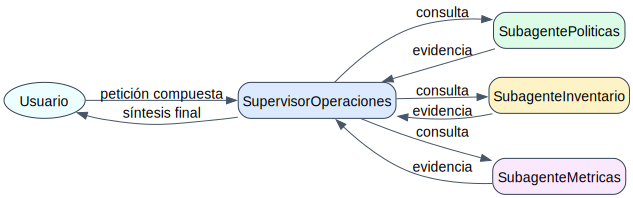

In [99]:
render_architecture_diagram("subagentes")

In [100]:
policy_agent = Agent(
    name="SubagentePoliticas",
    model=GENERATION_MODEL,
    instructions=(
        "Eres especialista en políticas internas. Usa search_internal_policy antes de responder. "
        "Devuelve solo evidencia relevante, fuentes y consecuencias operativas. "
        "No resuelvas inventario ni métricas comerciales."
    ),
    tools=[search_internal_policy, estimate_approval_path],
)

inventory_agent = Agent(
    name="SubagenteInventario",
    model=GENERATION_MODEL,
    instructions=(
        "Eres especialista en inventario corporativo. Usa check_inventory para productos y unidades. "
        "Indica disponibilidad, unidades faltantes, almacén, plazo y coste estimado. "
        "No decidas aprobaciones financieras."
    ),
    tools=[check_inventory],
)

regional_agent = Agent(
    name="SubagenteMetricasRegionales",
    model=GENERATION_MODEL,
    instructions=(
        "Eres analista de métricas regionales. Usa summarize_region_metrics antes de responder. "
        "Compara regiones solo con los datos disponibles y explica si una región parece prioritaria."
    ),
    tools=[summarize_region_metrics],
)


In [101]:
class SubagentSynthesis(BaseModel):
    answer: str = Field(description="Respuesta final integrada para el usuario.")
    consulted_subagents: list[str] = Field(description="Subagentes consultados.")
    evidence_summary: list[str] = Field(description="Evidencias principales usadas para decidir.")
    required_approvals: list[str] = Field(default_factory=list, description="Aprobaciones o validaciones necesarias.")
    next_action: str = Field(description="Siguiente acción recomendada.")


supervisor_agent = Agent(
    name="SupervisorOperaciones",
    model=GENERATION_MODEL,
    instructions=(
        "Eres supervisor de operaciones internas. Tu trabajo es decidir qué subagentes consultar y sintetizar una respuesta final. "
        "Consulta políticas para aprobaciones, inventario para stock y métricas regionales para priorización comercial. "
        "No delegues la respuesta final al usuario. Integra evidencias y señala incertidumbres."
    ),
    tools=[
        policy_agent.as_tool(
            tool_name="consultar_politicas",
            tool_description="Consulta a un subagente especializado en políticas internas y aprobaciones.",
        ),
        inventory_agent.as_tool(
            tool_name="consultar_inventario",
            tool_description="Consulta a un subagente especializado en stock, coste, almacén y plazo de hardware.",
        ),
        regional_agent.as_tool(
            tool_name="consultar_metricas_regionales",
            tool_description="Consulta a un subagente especializado en métricas comerciales por región.",
        ),
    ],
    output_type=SubagentSynthesis,
)


In [102]:
subagent_question = (
    "Necesito comprar 12 monitor-27 para EMEA porque el equipo comercial va a abrir nuevos dashboards. "
    "Comprueba stock, aprobación y prioridad regional."
)

subagent_result = await Runner.run(supervisor_agent, subagent_question)
print_agent_result("Subagentes con supervisor", subagent_result)
describe_run_items(subagent_result)


[Subagentes con supervisor]
Último agente: SupervisorOperaciones
Salida final:
answer='Para la compra de 12 monitores modelo monitor-27 para la región EMEA, la disponibilidad actual es de 8 unidades en el almacén de Madrid y se requieren 4 unidades adicionales, con un plazo de entrega estimado de 2 días. El coste total estimado es de aproximadamente 2,628 euros. Según las políticas internas, esta compra, por superar los 2.000 euros, requiere aprobación formal de Dirección y una orden de compra, además de la justificación y detalle del centro de coste y proveedor recomendado. Por otra parte, la justificación comercial para esta inversión es sólida, dado que la región EMEA tiene una alta prioridad basada en sus ingresos, margen, pipeline y tasa de conversión, mostrando un beneficio claro para optimizar procesos comerciales mediante nuevos dashboards. \n\nRecomiendo proceder con la solicitud de aprobación de Dirección y preparar la orden de compra, gestionar el pedido de las 8 unidades di

,step,item_type,agent,raw_type,name,arguments,output
0,1,ToolCallItem,SupervisorOperaciones,function_call,consultar_inventario,"{""input"":""monitor-27 stock en EMEA para compra...",
1,2,ToolCallItem,SupervisorOperaciones,function_call,consultar_politicas,"{""input"":""aprobación para compra de 12 monitor...",
2,3,ToolCallItem,SupervisorOperaciones,function_call,consultar_metricas_regionales,"{""input"":""prioridad comercial en EMEA para jus...",
3,4,ToolCallOutputItem,SupervisorOperaciones,function_call_output,consultar_inventario,,Para la compra de 12 unidades del monitor de 2...
4,5,ToolCallOutputItem,SupervisorOperaciones,function_call_output,consultar_politicas,,Para la compra de 12 monitores modelo monitor-...
5,6,ToolCallOutputItem,SupervisorOperaciones,function_call_output,consultar_metricas_regionales,,Para justificar la compra de monitores para nu...
6,7,MessageOutputItem,SupervisorOperaciones,message,,,"{""answer"":""Para la compra de 12 monitores mode..."


La lectura arquitectónica de esta ejecución está en `last_agent`: queremos que siga siendo `SupervisorOperaciones`. Los subagentes han trabajado, pero el control de la respuesta final no se ha transferido. Si la tabla de items muestra consultas a varios subagentes, el patrón está actuando como esperamos.

Este aislamiento tiene una ventaja didáctica muy clara. El subagente de inventario no necesita cargar las políticas completas de RRHH o Seguridad. El subagente de políticas no necesita conocer todos los detalles de stock. Cada uno ve un contexto más pequeño y produce una respuesta parcial. El supervisor solo recibe el resultado que necesita para componer la respuesta.

El riesgo es la coordinación excesiva. Si el supervisor consulta tres subagentes para una pregunta trivial, el sistema será más caro que la línea base sin aportar calidad. Por eso las instrucciones del supervisor deben expresar no solo qué puede consultar, sino cuándo merece la pena hacerlo. En producción también impondríamos límites de llamadas, timeouts y evaluación de rutas esperadas.


## 7. Arquitecturas jerárquicas

Una vez entendido el patrón de subagentes, podemos repetirlo por niveles. En una arquitectura jerárquica, un agente principal no consulta necesariamente a todos los especialistas finales. Puede consultar a coordinadores intermedios, y esos coordinadores pueden consultar a otros subagentes. Esto aparece en organizaciones reales: Dirección no habla con cada sistema operativo individual; pide una recomendación a un responsable de área, y ese responsable coordina Finanzas, IT, Seguridad o métricas.

La jerarquía aporta dos ventajas. La primera es aislamiento de contexto: el agente principal no necesita conocer todos los detalles de inventario, políticas y métricas si puede pedir una recomendación ya elaborada a un coordinador. La segunda es ownership: cada nivel puede mantener sus instrucciones y herramientas sin que el prompt principal se convierta en un manual interminable.

El coste es la opacidad. Cuantos más niveles añadimos, más importante es la observabilidad. Una respuesta final puede fallar porque el director eligió mal al coordinador, porque el coordinador no consultó al especialista adecuado o porque un especialista devolvió evidencia incompleta. Por eso una jerarquía solo merece la pena cuando reduce complejidad real y cuando tenemos trazas suficientes para reconstruir el camino.


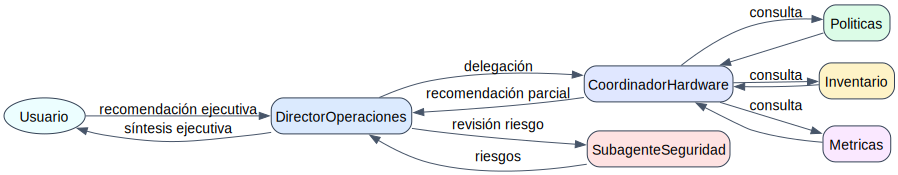

In [103]:
render_architecture_diagram("jerarquia")

In [104]:
class HierarchicalAnswer(BaseModel):
    answer: str = Field(description="Respuesta final del agente principal.")
    consulted_units: list[str] = Field(description="Coordinadores o especialistas consultados.")
    delegated_work: list[str] = Field(description="Trabajo delegado a niveles inferiores.")
    risks: list[str] = Field(default_factory=list, description="Riesgos o bloqueos detectados.")
    next_action: str = Field(description="Siguiente acción recomendada.")


security_agent = Agent(
    name="SubagenteSeguridad",
    model=GENERATION_MODEL,
    instructions=(
        "Eres especialista en Seguridad. Usa políticas internas para revisar accesos, SaaS y datos sensibles. "
        "Devuelve riesgos, evidencia y recomendación. No apruebes acciones sensibles sin evidencia."
    ),
    tools=[search_internal_policy],
)


hardware_purchase_coordinator = Agent(
    name="CoordinadorCompraHardware",
    model=GENERATION_MODEL,
    instructions=(
        "Eres coordinador de compras de hardware. No respondes como especialista único: coordinas políticas, "
        "inventario y métricas regionales. Consulta subagentes cuando haga falta y devuelve una recomendación integrada."
    ),
    tools=[
        policy_agent.as_tool(
            tool_name="coordinar_politicas",
            tool_description="Consulta a un subagente de políticas y aprobaciones.",
        ),
        inventory_agent.as_tool(
            tool_name="coordinar_inventario",
            tool_description="Consulta a un subagente de inventario de hardware.",
        ),
        regional_agent.as_tool(
            tool_name="coordinar_metricas_regionales",
            tool_description="Consulta a un subagente de métricas regionales.",
        ),
    ],
)


operations_director = Agent(
    name="DirectorOperaciones",
    model=GENERATION_MODEL,
    instructions=(
        "Eres el agente principal de una arquitectura jerárquica. Decide si necesitas consultar al coordinador "
        "de compras de hardware, al especialista de Seguridad o a ambos. Tu respuesta final debe explicar qué trabajo "
        "delegaste y qué riesgos quedan abiertos."
    ),
    tools=[
        hardware_purchase_coordinator.as_tool(
            tool_name="consultar_coordinador_hardware",
            tool_description="Coordina políticas, inventario y métricas para compras de hardware.",
        ),
        security_agent.as_tool(
            tool_name="consultar_seguridad",
            tool_description="Revisa riesgos de Seguridad, accesos o datos sensibles.",
        ),
    ],
    output_type=HierarchicalAnswer,
)


In [105]:
hierarchy_question = (
    "Queremos comprar 12 monitor-27 para EMEA y además evaluar una herramienta SaaS "
    "que recibirá datos de cliente. Dame una recomendación ejecutiva."
)

hierarchy_result = await Runner.run(operations_director, hierarchy_question)
print_agent_result("Jerarquía de agentes", hierarchy_result)
describe_run_items(hierarchy_result)


[Jerarquía de agentes]
Último agente: DirectorOperaciones
Salida final:
answer='Para la compra de los 12 monitores modelo 27 para la región EMEA, la recomendación es proceder con la solicitud basada en la disponibilidad actual y la necesidad de adquirir 4 unidades adicionales, asegurando la justificación y el circuito de aprobación necesarios. Para la evaluación de la herramienta SaaS que recibirá datos de clientes, es imprescindible solicitar una revisión y aprobación formal por parte del área de Seguridad debido a los riesgos relacionados con accesos, gestión de incidentes y protección de datos sensibles. Se recomienda además controlar estrictamente las altas con permisos administrativos y establecer protocolos de gestión de incidentes prioritarios.' consulted_units=['Coordinador de compras de hardware', 'Especialista de Seguridad'] delegated_work=['Preparar la solicitud de compra con justificación y circuito de aprobación para los monitores', 'Gestionar la revisión y aprobación form

,step,item_type,agent,raw_type,name,arguments,output
0,1,ToolCallItem,DirectorOperaciones,function_call,consultar_coordinador_hardware,"{""input"":""Solicitar recomendación para compra ...",
1,2,ToolCallItem,DirectorOperaciones,function_call,consultar_seguridad,"{""input"":""Evaluar riesgos de seguridad para he...",
2,3,ToolCallOutputItem,DirectorOperaciones,function_call_output,consultar_coordinador_hardware,,Para la compra de 12 monitores modelo 27 para ...
3,4,ToolCallOutputItem,DirectorOperaciones,function_call_output,consultar_seguridad,,Riesgos de seguridad evaluados para la herrami...
4,5,MessageOutputItem,DirectorOperaciones,message,,,"{""answer"":""Para la compra de los 12 monitores ..."


La ejecución debería leerse por niveles. El último agente debe seguir siendo `DirectorOperaciones`, porque es quien conserva la responsabilidad ejecutiva. Sin embargo, dentro de la traza deberían aparecer llamadas a coordinadores o especialistas. El coordinador de hardware, a su vez, puede consultar políticas, inventario y métricas. Esta es la diferencia entre una arquitectura plana y una jerárquica: el agente principal no necesita hablar con cada especialista final.

Este patrón no debe usarse para parecer sofisticados. Si hay tres especialistas y un supervisor los coordina bien, una jerarquía adicional puede sobrar. Empieza a tener sentido cuando aparecen áreas completas con coordinación interna propia, cuando distintos equipos mantienen diferentes capas o cuando el agente principal necesita recibir recomendaciones ya consolidadas.


## 8. Planner/Executor: separar plan, revisión y ejecución

Planner/executor separa dos actividades que en un agente único suelen mezclarse: decidir qué trabajo hay que hacer y ejecutar ese trabajo. El planner recibe la solicitud y produce un plan estructurado. Ese plan no se ejecuta automáticamente: primero se presenta al usuario o a un sistema de revisión para aprobarlo, rechazarlo o pedir modificaciones. Solo después de la confirmación se entrega al executor.

Esta separación aporta auditabilidad y control. El plan puede mostrarse en una interfaz, guardarse en un ticket, validarse con reglas deterministas o quedar bloqueado cuando toca compras, permisos, datos sensibles o acciones irreversibles. Si el usuario pide cambios, vuelve al planner con instrucciones concretas. Si el usuario aprueba, el executor usa herramientas para recopilar evidencia y redactar la respuesta final.

No conviene usar planner/executor para preguntas simples. Si alguien pregunta "¿hay stock de dock-usb-c?", generar un plan formal y pedir confirmación añade latencia sin aportar control. El patrón merece la pena cuando el trabajo es abierto, multi-paso, sensible o necesita dejar evidencia de por qué se siguió un camino.


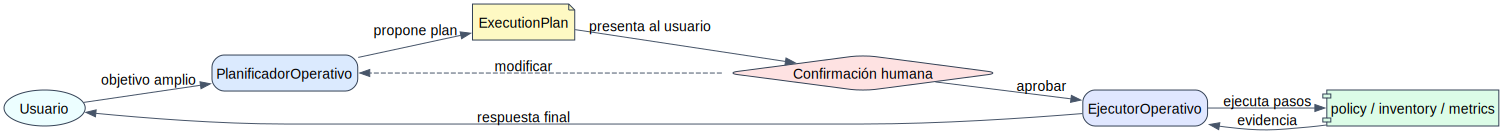

In [106]:
render_architecture_diagram("planner_executor")

In [107]:
class PlanStep(BaseModel):
    order: int = Field(description="Orden de ejecución empezando en 1.")
    objective: str = Field(description="Qué debe averiguarse o producirse.")
    capability: Literal["policy", "inventory", "metrics", "security", "synthesis"] = Field(
        description="Tipo de capacidad necesaria."
    )
    expected_evidence: str = Field(description="Evidencia esperada para completar el paso.")


class ExecutionPlan(BaseModel):
    user_goal: str = Field(description="Objetivo operativo interpretado.")
    steps: list[PlanStep] = Field(description="Pasos propuestos.")
    needs_human_review_before_execution: bool = Field(
        description="True si hay coste, permisos, datos sensibles o acción irreversible."
    )
    reason_for_review: str | None = Field(default=None, description="Motivo de revisión humana.")


planner_agent = Agent(
    name="PlanificadorOperativo",
    model=GENERATION_MODEL,
    instructions=(
        "Eres un planificador operativo. No ejecutes herramientas ni respondas al usuario final. "
        "Convierte la petición en un plan breve, ordenado y auditable. Marca revisión humana si hay compras, "
        "aprobaciones, Seguridad, datos sensibles o acciones con impacto operativo. "
        "Si recibes un plan existente junto con cambios solicitados por el usuario, devuelve una versión revisada "
        "del plan que incorpore esos cambios."
    ),
    output_type=ExecutionPlan,
)


executor_agent = Agent(
    name="EjecutorOperativo",
    model=GENERATION_MODEL,
    instructions=(
        "Eres un ejecutor operativo. Recibes una petición, un plan estructurado y una confirmación explícita. "
        "Ejecuta solo planes aprobados por el usuario. Usa herramientas disponibles y entrega una respuesta final "
        "basada en evidencia. Si falta aprobación, detén la ejecución y solicita confirmación."
    ),
    tools=[search_internal_policy, check_inventory, summarize_region_metrics],
)


In [108]:
planner_question = (
    "Evalúa si podemos comprar 4 laptop-pro-14 para nuevas incorporaciones en EMEA "
    "y qué habría que revisar antes de aprobarlo."
)

plan_result = await Runner.run(planner_agent, planner_question)
execution_plan: ExecutionPlan = plan_result.final_output
print(execution_plan.model_dump_json(indent=2))


{
  "user_goal": "Evaluar la compra de 4 laptop-pro-14 para nuevas incorporaciones en EMEA y determinar qué revisar antes de aprobarla.",
  "steps": [
    {
      "order": 1,
      "objective": "Verificar la justificación y necesidad de las laptops para nuevas incorporaciones en EMEA.",
      "capability": "policy",
      "expected_evidence": "Informe o comunicación que explique la necesidad de estas laptops para el equipo y las incorporaciones."
    },
    {
      "order": 2,
      "objective": "Revisar el presupuesto disponible para la compra de las 4 laptops en la región EMEA.",
      "capability": "metrics",
      "expected_evidence": "Estado actualizado del presupuesto que permita confirmar disponibilidad o limitaciones financieras."
    },
    {
      "order": 3,
      "objective": "Consultar con el departamento de TI para confirmar especificaciones, compatibilidad y soporte de las laptop-pro-14.",
      "capability": "inventory",
      "expected_evidence": "Confirmación técnica 

Antes de ejecutar, el plan se somete a revisión humana. En una aplicación real este paso podría ser una pantalla de aprobación, un comentario en un ticket o una regla de negocio que exige validación manual. En el notebook usamos `input()` para hacerlo explícito: escribir `aprobar` permite continuar, `cancelar` detiene el flujo y cualquier otro texto se interpreta como una petición de modificación del plan.


In [110]:
def plan_to_dataframe(plan: ExecutionPlan) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "order": step.order,
            "capability": step.capability,
            "objective": step.objective,
            "expected_evidence": step.expected_evidence,
        }
        for step in plan.steps
    )


async def review_plan_until_approved(
    initial_plan: ExecutionPlan,
    user_request: str,
) -> tuple[ExecutionPlan, bool, list[str], list[Any]]:
    current_plan = initial_plan
    review_history: list[str] = []
    revised_plan_results: list[Any] = []

    while True:
        display(plan_to_dataframe(current_plan))
        if current_plan.needs_human_review_before_execution:
            print("Motivo de revisión:", current_plan.reason_for_review)

        decision = input(
            "Escribe 'aprobar' para ejecutar, 'cancelar' para detener, "
            "o describe cambios que quieres aplicar al plan: "
        ).strip()
        normalized_decision = decision.lower()

        if normalized_decision in {"", "aprobar", "aprobado", "ok", "si", "sí", "approve"}:
            return current_plan, True, review_history, revised_plan_results

        if normalized_decision in {"cancelar", "cancel", "detener", "stop"}:
            return current_plan, False, review_history, revised_plan_results

        review_history.append(decision)
        revision_input = {
            "original_user_request": user_request,
            "current_plan": current_plan.model_dump(),
            "requested_changes": decision,
        }
        revised_result = await Runner.run(planner_agent, to_json(revision_input))
        revised_plan_results.append(revised_result)
        current_plan = revised_result.final_output


execution_plan, plan_approved, plan_review_history, revised_plan_results = await review_plan_until_approved(
    execution_plan,
    planner_question,
)

print("Plan aprobado:", plan_approved)
print("Revisiones solicitadas:", plan_review_history)


,order,capability,objective,expected_evidence
0,1,policy,Verificar la justificación y necesidad de las ...,Informe o comunicación que explique la necesid...
1,2,metrics,Revisar el presupuesto disponible para la comp...,Estado actualizado del presupuesto que permita...
2,3,inventory,Consultar con el departamento de TI para confi...,Confirmación técnica del departamento de TI so...
3,4,security,Verificar las políticas de seguridad y cumplim...,Documentación o directrices de seguridad que i...
4,5,metrics,Estimar y revisar los costos totales incluyend...,Cotización final que incluya todos los costos ...


Motivo de revisión: La compra involucra gasto presupuestario y aspectos de seguridad, por lo que requiere aprobación y revisión humana antes de proceder.


,order,capability,objective,expected_evidence
0,1,policy,Verificar la justificación y necesidad de las ...,Informe o comunicación que explique la necesid...
1,2,metrics,Revisar el presupuesto disponible para la comp...,Estado actualizado del presupuesto que permita...
2,3,inventory,Consultar con el departamento de TI para confi...,Confirmación técnica del departamento de TI so...
3,4,security,Verificar las políticas de seguridad y cumplim...,Documentación o directrices de seguridad que i...
4,5,metrics,Estimar y revisar los costos totales incluyend...,Cotización final que incluya todos los costos ...
5,6,policy,Realizar una validación final con los responsa...,Aprobación formal por parte de los responsable...


Motivo de revisión: La compra involucra gasto presupuestario y aspectos de seguridad, además de requerir aprobación formal, por lo que requiere revisión humana antes de proceder.
Plan aprobado: True
Revisiones solicitadas: ['Incluye un paso de validación adicional']


In [111]:
if not plan_approved:
    raise RuntimeError("El plan no está aprobado. No se ejecuta hasta recibir confirmación humana.")

executor_input = {
    "user_request": planner_question,
    "approved": plan_approved,
    "review_history": plan_review_history,
    "execution_plan": execution_plan.model_dump(),
}

executor_result = await Runner.run(executor_agent, to_json(executor_input))
print_agent_result("Planner/Executor", executor_result)
describe_run_items(executor_result)


[Planner/Executor]
Último agente: EjecutorOperativo
Salida final:
Resumen de la evaluación para compra de 4 laptop-pro-14 para nuevas incorporaciones en EMEA:

1. Justificación: Las políticas de IT priorizan la asignación de hardware a nuevas incorporaciones. Es necesario confirmar la comunicación o informe que explique esta necesidad específica en EMEA.
2. Presupuesto: La región EMEA presenta un margen operativo sólido (40.1%) y un pipeline saludable, lo que sugiere capacidad financiera para aprovisionar estos gastos.
3. Inventario y especificaciones: Hay 5 unidades disponibles en el almacén de Madrid, suficiente para cubrir las 4 solicitadas. El precio unitario es 1499 EUR, totalizando aproximadamente 5996 EUR.
4. Seguridad: No hay restricciones específicas para la compra de hardware, salvo que el software asociado a los dispositivos con datos sensibles debe revisarse por seguridad. Se debe confirmar que el uso de estos portátiles cumple con las políticas de seguridad y que cualquier

,step,item_type,agent,raw_type,name,arguments,output
0,1,MessageOutputItem,EjecutorOperativo,message,,,La petición para evaluar la compra de 4 laptop...
1,2,ToolCallItem,EjecutorOperativo,function_call,search_internal_policy,"{""query"":""justificación necesidad laptops nuev...",
2,3,ToolCallItem,EjecutorOperativo,function_call,summarize_region_metrics,{},
3,4,ToolCallItem,EjecutorOperativo,function_call,check_inventory,"{""product_id"":""laptop-pro-14"",""requested_units...",
4,5,ToolCallItem,EjecutorOperativo,function_call,search_internal_policy,"{""query"":""políticas de seguridad adquisición u...",
5,6,ToolCallOutputItem,EjecutorOperativo,function_call_output,search_internal_policy,,"[ { ""source"": ""finanzas_compras.md"", ""area"": ""..."
6,7,ToolCallOutputItem,EjecutorOperativo,function_call_output,summarize_region_metrics,,"[ { ""region"": ""EMEA"", ""revenue_eur"": 1820000, ..."
7,8,ToolCallOutputItem,EjecutorOperativo,function_call_output,check_inventory,,"{ ""product_id"": ""laptop-pro-14"", ""name"": ""Port..."
8,9,ToolCallOutputItem,EjecutorOperativo,function_call_output,search_internal_policy,,"[ { ""source"": ""seguridad_accesos.md"", ""area"": ..."
9,10,MessageOutputItem,EjecutorOperativo,message,,,Resumen de la evaluación para compra de 4 lapt...


La lectura importante es que el plan aparece como objeto intermedio, no como texto decorativo. Una aplicación puede mostrarlo al usuario, guardarlo en un ticket, validarlo con reglas deterministas o bloquearlo si pide capacidades no permitidas. El executor no rediseña el trabajo desde cero: recibe un plan aprobado y su responsabilidad es ejecutarlo con herramientas, dejando claro qué evidencia respalda la respuesta.


## 10. MCP: herramientas externas con un protocolo común

Hasta ahora las herramientas viven en el notebook. Eso es cómodo para clase, pero no escala bien cuando varias aplicaciones necesitan consumir las mismas capacidades. MCP, Model Context Protocol, es un protocolo abierto y estándar para que aplicaciones y agentes descubran y usen capacidades externas de una forma común. Formalmente, un servidor MCP puede exponer herramientas (`tools`), recursos (`resources`) y prompts (`prompts`); un cliente MCP los descubre mediante mensajes del protocolo y decide cómo incorporarlos al trabajo del modelo.

La idea clave es separar contrato de implementación. Para el agente, una herramienta MCP tiene nombre, descripción, esquema de entrada y resultado. El agente no necesita saber si por detrás hay una función Python, una API HTTP, una consulta SQL, un CRM, un sistema de tickets, un repositorio de documentación o un conector SaaS. Eso permite reutilizar servidores ya existentes y también construir servidores propios. La especificación oficial del protocolo está en https://modelcontextprotocol.io/specification/latest y la documentación conceptual en https://modelcontextprotocol.io/docs/learn/architecture.

OpenAI soporta MCP en varios niveles. En la Responses API se pueden usar servidores MCP remotos y conectores mantenidos por OpenAI. En el Agents SDK se pueden usar servidores hospedados mediante `HostedMCPTool`, servidores remotos por Streamable HTTP o SSE y servidores locales por `stdio`. Nuestro ejemplo local por `stdio` es solo una opción cómoda para clase, no la definición de MCP. Referencias oficiales: https://developers.openai.com/api/docs/guides/tools-connectors-mcp y https://openai.github.io/openai-agents-python/mcp/.

También es importante la parte de seguridad. Un servidor MCP puede ver información que entra en el contexto del modelo y puede pedir argumentos para ejecutar acciones externas. Por eso hay que revisar qué servidor se conecta, filtrar herramientas, pedir aprobación humana en operaciones sensibles, cachear `list_tools()` con criterio y tratar descripciones/anotaciones de servidores no confiables como contenido potencialmente no fiable.


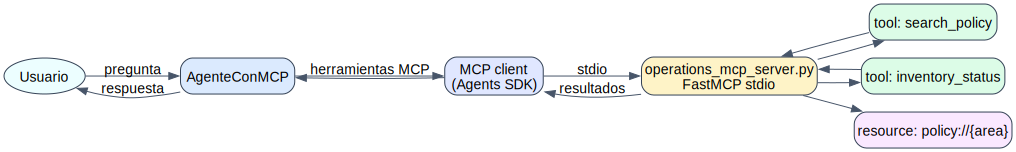

In [82]:
render_architecture_diagram("mcp")

### 10.1. MCP remoto, conectores y servidores ya existentes

Antes de crear nuestro propio servidor, vamos a usar servidores que ya existen. MCP es el contrato estándar de descubrimiento y llamada de herramientas. `stdio`, Streamable HTTP, SSE o herramientas hospedadas son formas distintas de transportar ese contrato.

Los ejemplos siguientes usan MCP remoto. La primera llama a un servidor público de dados desde la Responses API. La segunda usa `HostedMCPTool` desde el Agents SDK para consultar DeepWiki sobre `openai/openai-agents-python`. La tercera usa el servidor MCP remoto de documentación de OpenAI mediante Streamable HTTP.


#### 10.1.1. Servidor MCP remoto desde Responses API

Aquí usamos un servidor MCP público de ejemplo. La llamada no crea ningún servidor local: enviamos a la Responses API la URL del servidor remoto y la API importa sus herramientas. En la respuesta aparecen items específicos de MCP: `mcp_list_tools`, cuando se descubren las herramientas, y `mcp_call`, cuando el modelo invoca una de ellas.


In [ ]:
def describe_response_output(response: Any) -> pd.DataFrame:
    rows = []
    for index, item in enumerate(response.output, start=1):
        rows.append(
            {
                "step": index,
                "type": getattr(item, "type", ""),
                "name": getattr(item, "name", ""),
                "server_label": getattr(item, "server_label", ""),
                "arguments": compact(getattr(item, "arguments", "")),
                "output": compact(getattr(item, "output", getattr(item, "tools", ""))),
            }
        )
    return pd.DataFrame(rows)


remote_mcp_client = OpenAI(timeout=45)
remote_mcp_response = remote_mcp_client.responses.create(
    model=GENERATION_MODEL,
    tools=[
        {
            "type": "mcp",
            "server_label": "dmcp",
            "server_description": "Servidor MCP de ejemplo para tirar dados.",
            "server_url": "https://dmcp-server.deno.dev/sse",
            "require_approval": "never",
        }
    ],
    input="Roll 2d4+1 and tell me only the numeric result.",
)

print("Resultado final:", remote_mcp_response.output_text)
describe_response_output(remote_mcp_response)


#### 10.1.2. Servidor hospedado con `HostedMCPTool`

En el Agents SDK, `HostedMCPTool` delega el recorrido completo de herramientas MCP en la infraestructura de OpenAI. Nuestro proceso Python no abre una conexión MCP local ni llama manualmente a `list_tools()`. El agente recibe una herramienta hospedada con `server_label` y `server_url`, y la Responses API se encarga de descubrir e invocar las herramientas del servidor remoto.

Usamos DeepWiki como ejemplo porque es un servidor MCP público útil para consultar documentación de repositorios. La pregunta pide información sobre `openai/openai-agents-python`, el SDK que estamos usando en el notebook.


In [ ]:
deepwiki_agent = Agent(
    name="AgenteConDeepWikiMCP",
    model=GENERATION_MODEL,
    instructions=(
        "Usa DeepWiki para responder preguntas sobre repositorios. "
        "Responde de forma breve y no inventes si el servidor no devuelve evidencia."
    ),
    tools=[
        HostedMCPTool(
            tool_config={
                "type": "mcp",
                "server_label": "deepwiki",
                "server_url": "https://mcp.deepwiki.com/mcp",
                "require_approval": "never",
            }
        )
    ],
)

deepwiki_question = (
    "Según DeepWiki, ¿qué es openai/openai-agents-python y para qué sirve? "
    "Responde en dos frases."
)

deepwiki_result = await Runner.run(deepwiki_agent, deepwiki_question)
print_agent_result("Agente con DeepWiki MCP", deepwiki_result)
describe_run_items(deepwiki_result)


#### 10.1.3. Servidor MCP remoto de documentación de OpenAI

Este ejemplo usa el servidor MCP público de documentación de OpenAI: `https://developers.openai.com/mcp`. Es un servidor remoto de solo lectura por Streamable HTTP. Primero listamos sus herramientas para ver qué publica; después damos el servidor a un agente y le pedimos que consulte documentación oficial.


In [ ]:
openai_docs_question = (
    "Busca en la documentación oficial de OpenAI qué papel cumple MCP en la Responses API. "
    "Responde en dos frases."
)

async with MCPServerStreamableHttp(
    name="openai_docs",
    params={"url": "https://developers.openai.com/mcp"},
    cache_tools_list=True,
    tool_filter=create_static_tool_filter(
        allowed_tool_names=["search_openai_docs", "fetch_openai_doc"],
    ),
) as openai_docs_server:
    openai_docs_tools = await openai_docs_server.list_tools()
    display(
        pd.DataFrame(
            {
                "tool": tool.name,
                "description": compact(tool.description, limit=160),
            }
            for tool in openai_docs_tools
        )
    )

    openai_docs_agent = Agent(
        name="AgenteDocsOpenAI",
        model=GENERATION_MODEL,
        instructions=(
            "Usa el servidor MCP de documentación de OpenAI para responder. "
            "Si encuentras la página fuente, menciona su título o tema."
        ),
        mcp_servers=[openai_docs_server],
        mcp_config={
            "convert_schemas_to_strict": True,
            "include_server_in_tool_names": True,
        },
    )
    openai_docs_result = await Runner.run(openai_docs_agent, openai_docs_question)

print_agent_result("Agente con Docs MCP remoto", openai_docs_result)
describe_run_items(openai_docs_result)


#### 10.1.4. Conectores MCP y OAuth

Los conectores mantenidos por OpenAI siguen el mismo patrón conceptual, pero normalmente requieren autorización OAuth. Por eso no ejecutamos aquí Dropbox, Google Drive o Google Calendar sin credenciales del alumno. La forma relevante es que cambia `server_url` por `connector_id` y se añade `authorization`. En una aplicación real, ese token lo obtendríamos mediante el flujo OAuth de nuestro producto y decidiríamos qué acciones requieren aprobación humana.


In [ ]:
dropbox_connector_config = {
    "type": "mcp",
    "server_label": "Dropbox",
    "connector_id": "connector_dropbox",
    "authorization": "<oauth access token>",
    "require_approval": "never",
}

dropbox_connector_config


Con esto ya podemos situar nuestro ejemplo local: no lo hacemos porque MCP obligue a usar `stdio`, sino porque `stdio` permite enseñar el ciclo completo sin desplegar nada en internet. La arquitectura es la misma: un cliente MCP descubre herramientas de un servidor; cambia el transporte y dónde se ejecuta la llamada.


### 10.2. Crear un servidor MCP local

El servidor de ejemplo está en `mcp_servers/operations_mcp_server.py`. No es una función del notebook: es un proceso independiente que publica herramientas MCP. Esto es lo que queremos enseñar: la capacidad puede vivir fuera del agente, con su propio ciclo de vida, su propio despliegue y sus propias reglas de seguridad.

El servidor usa `FastMCP` y publica dos herramientas: `search_policy`, para buscar políticas internas, e `inventory_status`, para consultar inventario. También publica un recurso `policy://{area}`. En un proyecto real podríamos publicar herramientas contra una base de datos, un CRM, un data warehouse, GitHub, un sistema de tickets o cualquier API interna.


In [83]:
MCP_SERVER_PATH = SESSION_DIR / "mcp_servers" / "operations_mcp_server.py"

async with MCPServerStdio(
    params={
        "command": sys.executable,
        "args": [str(MCP_SERVER_PATH)],
    },
    name="operaciones_local",
    cache_tools_list=True,
    tool_filter=create_static_tool_filter(
        allowed_tool_names=["search_policy", "inventory_status"],
    ),
) as operations_mcp_server:
    mcp_tools = await operations_mcp_server.list_tools()


for tool in mcp_tools:
    print("\nTool:", tool.name)
    print("Description:", tool.description)
    print("Input Schema:", compact(tool.inputSchema, limit=180))



Tool: search_policy
Description: Busca políticas internas relevantes para una consulta.
Input Schema: {'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'search_policyArguments', 'type': 'object'}

Tool: inventory_status
Description: Consulta stock, coste y disponibilidad de un producto de hardware.
Input Schema: {'properties': {'product_id': {'title': 'Product Id', 'type': 'string'}, 'requested_units': {'default': 1, 'title': 'Requested Units', 'type': 'integer'}}, 'required': ['product_id...


In [ ]:
mcp_question = "Consulta por MCP si puedo pedir 12 monitor-27 y qué política de compra aplica."

async with MCPServerStdio(
    params={
        "command": sys.executable,
        "args": [str(MCP_SERVER_PATH)],
    },
    name="operaciones_local",
    cache_tools_list=True,
    tool_filter=create_static_tool_filter(
        allowed_tool_names=["search_policy", "inventory_status"],
    ),
) as operations_mcp_server:
    mcp_agent = Agent(
        name="AgenteConMCP",
        model=GENERATION_MODEL,
        instructions=(
            "Eres un asistente de operaciones que usa herramientas publicadas por un servidor MCP. "
            "Usa las herramientas MCP para políticas e inventario cuando la pregunta dependa de datos internos."
        ),
        mcp_servers=[operations_mcp_server],
        mcp_config={
            "convert_schemas_to_strict": True,
            "include_server_in_tool_names": True,
        },
    )
    mcp_result = await Runner.run(mcp_agent, mcp_question)

print_agent_result("Agente con MCP local", mcp_result)
describe_run_items(mcp_result)


La diferencia con `@function_tool` es arquitectónica. Una función decorada vive dentro del proceso de la aplicación. Un servidor MCP publica capacidades que pueden ser consumidas por distintos clientes. El agente no necesita conocer cómo está implementada la búsqueda de políticas; solo ve herramientas MCP con nombre, descripción y esquema.

Hay que diseñar MCP con cuidado. Un servidor puede exponer demasiadas herramientas, pedir parámetros innecesarios o acceder a datos sensibles. Por eso conviene filtrar herramientas, cachear la lista solo cuando las definiciones sean estables, exigir aprobación para acciones sensibles y revisar qué datos viajan entre el agente y el servidor. La documentación oficial de OpenAI también advierte de riesgos de prompt injection y privacidad al conectar servidores MCP personalizados.


## 11. Skills: archivos `SKILL.md` montados en el agente

Las skills son una forma de proporcionar al agente conocimiento operativo especializado sin convertir cada especialidad en un agente independiente. En un ejemplo real no deberían definirse como strings dentro del notebook. Lo normal es que vivan en el proyecto como carpetas propias, cada una con su `SKILL.md` y, si hace falta, subcarpetas de apoyo. El agente recibe un índice de skills disponibles y puede abrir el archivo de la skill que necesite durante la ejecución.

Esta sección usa esa estructura real. En `skills/operaciones/` hay cuatro carpetas: `compras_finanzas`, `hardware_it`, `priorizacion_regional` y `seguridad_accesos`. Cada una contiene un `SKILL.md` con frontmatter de nombre y descripción, seguido de instrucciones de trabajo. Algunas skills incluyen además `references/`, `scripts/` o `assets/`. Esas carpetas también forman parte de la skill: no son agentes nuevos, sino material auxiliar que el `SKILL.md` puede recomendar leer o ejecutar cuando sea útil.

La diferencia entre estas carpetas es práctica. `references/` suele contener documentación que el agente debe consultar bajo demanda: tablas, criterios, formatos, políticas resumidas o esquemas. `scripts/` contiene utilidades ejecutables que encapsulan lógica repetible. `assets/` contiene plantillas, ejemplos, imágenes, fixtures u otros artefactos reutilizables. Si se trabaja con `Skill(...)` como objeto del SDK, esos nombres existen como campos explícitos: `scripts`, `references` y `assets`. Si se monta una carpeta local con `LocalDir`, el árbol se copia completo, así que también podríamos tener otras carpetas convencionales como `resources/`; simplemente no tienen semántica especial salvo que el `SKILL.md` indique cómo usarlas.

Las skills no sustituyen a las herramientas. Una skill explica cómo trabajar en un dominio: qué mirar primero, qué evidencias pedir, qué errores evitar y qué criterios aplicar. Las herramientas siguen siendo capacidades ejecutables: consultar políticas, revisar inventario, estimar aprobaciones o resumir métricas. Esta separación es sana porque permite que una misma herramienta sea usada desde distintas skills y que una skill combine varias herramientas sin convertirse en una función gigante.

La capacidad `Skills(from_=LocalDir(...))` copia la carpeta local de skills al workspace del `SandboxAgent`, bajo `.agents/`. Durante la preparación del run, el SDK añade al agente el índice de skills disponibles y las reglas de uso. Cuando la petición encaja con una skill, el agente puede abrir `.agents/<skill>/SKILL.md` y, desde ahí, seguir los enlaces a `.agents/<skill>/references/`, `.agents/<skill>/scripts/` o `.agents/<skill>/assets/`.

En este ejemplo usamos `Shell()` junto con `Skills(...)`, en lugar de `Capabilities.default()`. La razón es práctica: `Capabilities.default()` añade también herramientas de filesystem orientadas a edición, como `apply_patch`. En algunos modelos esa herramienta se envía como tipo `custom` y puede ser rechazada por la API. Para leer skills desde archivos no necesitamos editar el filesystem; con `Shell()` basta para inspeccionar los `SKILL.md` y recursos auxiliares montados en `.agents/`.


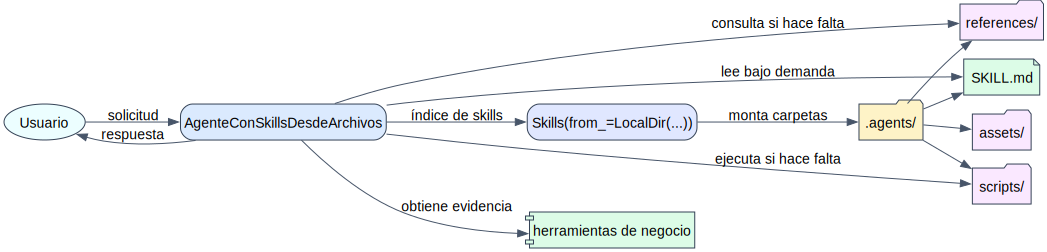

In [84]:
render_architecture_diagram("skills")

In [45]:
SKILLS_SOURCE_DIR = SESSION_DIR / "skills" / "operaciones"


def assert_skill_files_exist(skill_root: Path) -> None:
    if not skill_root.exists():
        raise FileNotFoundError(f"No existe el directorio de skills: {skill_root}")

    missing_skill_md = [
        child.name
        for child in sorted(skill_root.iterdir())
        if child.is_dir() and not (child / "SKILL.md").exists()
    ]
    if missing_skill_md:
        raise FileNotFoundError(f"Skills sin SKILL.md: {missing_skill_md}")


assert_skill_files_exist(SKILLS_SOURCE_DIR)
print("Directorio local de skills:", SKILLS_SOURCE_DIR)
print("Skills encontradas:", [path.name for path in sorted(SKILLS_SOURCE_DIR.iterdir()) if path.is_dir()])


Directorio local de skills: /Users/aruizart/Documents/01. Trabajo/02. Pontia/01. Máster IA/01. Large Language Models/sesion_06/skills/operaciones
Skills encontradas: ['compras_finanzas', 'hardware_it', 'priorizacion_regional', 'seguridad_accesos']


In [46]:
operation_skills_capability = Skills(
    from_=LocalDir(src=SKILLS_SOURCE_DIR),
    skills_path=".agents",
)


skill_agent = SandboxAgent(
    name="AgenteConSkillsDesdeArchivos",
    model=GENERATION_MODEL,
    instructions=(
        "Eres un asistente interno de operaciones. Tienes skills montadas en el sandbox. "
        "Cuando una solicitud encaje con una skill disponible, abre su `SKILL.md` y sigue sus instrucciones. "
        "Usa las herramientas de negocio para obtener evidencia concreta antes de recomendar acciones. "
        "Si varias skills son relevantes, usa la combinación mínima necesaria y explica qué evidencia procede de cada dominio."
    ),
    tools=[
        search_internal_policy,
        check_inventory,
        summarize_region_metrics,
        estimate_approval_path,
    ],
    capabilities=[Shell(), operation_skills_capability],
)


skill_run_config = RunConfig(
    sandbox=SandboxRunConfig(
        client=UnixLocalSandboxClient(),
    )
)


In [47]:
def parse_skill_frontmatter(skill_md: Path) -> dict[str, str]:
    text = skill_md.read_text(encoding="utf-8")
    if not text.startswith("---"):
        return {}

    _, frontmatter, _ = text.split("---", 2)
    metadata = {}
    for line in frontmatter.splitlines():
        if ":" not in line:
            continue
        key, value = line.split(":", 1)
        metadata[key.strip()] = value.strip()
    return metadata


def skill_support_folders(skill_dir: Path) -> str:
    expected = ["references", "scripts", "assets", "resources"]
    present = [name for name in expected if (skill_dir / name).is_dir()]
    return ", ".join(present) if present else ""


def skill_file_index(skill_root: Path) -> pd.DataFrame:
    rows = []
    for skill_dir in sorted(path for path in skill_root.iterdir() if path.is_dir()):
        skill_md = skill_dir / "SKILL.md"
        metadata = parse_skill_frontmatter(skill_md)
        rows.append(
            {
                "name": metadata.get("name", skill_dir.name),
                "description": metadata.get("description", ""),
                "local_file": str(skill_md.relative_to(SESSION_DIR)),
                "support_folders": skill_support_folders(skill_dir),
                "mounted_file": f"{operation_skills_capability.skills_path}/{skill_dir.name}/SKILL.md",
            }
        )
    return pd.DataFrame(rows)


skill_file_index(SKILLS_SOURCE_DIR)


,name,description,local_file,support_folders,mounted_file
0,compras_finanzas,"Aprobaciones de compra, importes, proveedores ...",skills/operaciones/compras_finanzas/SKILL.md,"references, scripts, assets",.agents/compras_finanzas/SKILL.md
1,hardware_it,"Inventario de hardware, stock, plazos de entre...",skills/operaciones/hardware_it/SKILL.md,"references, scripts",.agents/hardware_it/SKILL.md
2,priorizacion_regional,"Priorizacion por region usando revenue, margen...",skills/operaciones/priorizacion_regional/SKILL.md,references,.agents/priorizacion_regional/SKILL.md
3,seguridad_accesos,"Revision de seguridad, accesos administrativos...",skills/operaciones/seguridad_accesos/SKILL.md,"references, assets",.agents/seguridad_accesos/SKILL.md


In [ ]:
skill_question = (
    "Para EMEA quiero comprar 12 monitor-27. "
    "Necesito entender stock, aprobación y si la región lo justifica."
)

skill_result = await Runner.run(
    skill_agent,
    skill_question,
    run_config=skill_run_config,
)

print_agent_result("Agente con skills desde archivos", skill_result)
describe_run_items(skill_result)


En un proyecto real, las skills viven en el sistema de archivos y el agente solo recibe la ubicación donde debe encontrarlas. La skill define el método de trabajo del dominio; las herramientas ejecutan consultas concretas; el agente decide qué skill aplicar en función de la petición. Si se amplía la skill de Seguridad con una matriz de riesgo, una plantilla de revisión SaaS o un script de validación, la superficie de descubrimiento se mantiene estable: se añaden recursos a `skills/operaciones/seguridad_accesos/` y el `SKILL.md` explica cuándo usarlos.

La estructura de una skill se puede leer como una pequeña unidad de producto. `SKILL.md` es la puerta de entrada y debe decir cuándo usar la skill. `references/` contiene conocimiento que no conviene meter siempre en el contexto. `scripts/` permite ejecutar lógica auxiliar y reproducible. `assets/` guarda plantillas o artefactos reutilizables. Otras carpetas pueden existir como convención del proyecto, pero el agente solo las usará bien si el `SKILL.md` explica su propósito.

Las skills son especialmente útiles cuando la especialización es principalmente procedimental: guías, criterios, formatos de salida, scripts auxiliares y referencias. Si necesitamos que varios especialistas razonen de forma aislada y devuelvan opiniones parciales, subagentes será más natural. Si necesitamos que la conversación cambie de dueño, handoffs. Si necesitamos consultar especialistas independientes y sintetizar sus respuestas, subagentes. La skill sirve para cargar método y contexto especializado dentro del trabajo de un agente, no para reemplazar todos los demás patrones.


## 12. Comparativa de llamadas y tokens

Las arquitecturas no solo se eligen por elegancia conceptual. Cambian el número de llamadas al modelo, la cantidad de tokens de entrada, los tokens de salida y el número de pasos de ejecución que luego tendremos que observar y depurar. La tabla se construye con el `usage` real que devuelven las ejecuciones anteriores del notebook.

Para que esta comparativa tenga sentido, ejecuta primero las celdas de cada arquitectura: agente único, handoffs, subagentes, jerarquía, planner/executor, MCP y skills. La comparación recoge los objetos `*_result` ya generados y suma sus métricas. En planner/executor se suman la planificación, las posibles revisiones del plan y la ejecución aprobada; en handoffs se suman el turno inicial y la continuación; en MCP se separan el ejemplo local de los ejemplos remotos para que se vea que el transporte y el servidor también afectan al coste.


In [ ]:
def usage_attr(usage: Any, name: str, default: int = 0) -> int:
    value = getattr(usage, name, default) if usage is not None else default
    return int(value or 0)


def cached_input_tokens(usage: Any) -> int:
    details = getattr(usage, "input_tokens_details", None)
    return usage_attr(details, "cached_tokens")


def reasoning_output_tokens(usage: Any) -> int:
    details = getattr(usage, "output_tokens_details", None)
    return usage_attr(details, "reasoning_tokens")


def run_result_usage(run_result: Any) -> dict[str, int]:
    usage = getattr(getattr(run_result, "context_wrapper", None), "usage", None)
    if usage is not None:
        return {
            "model_requests": usage_attr(usage, "requests"),
            "input_tokens": usage_attr(usage, "input_tokens"),
            "cached_input_tokens": cached_input_tokens(usage),
            "output_tokens": usage_attr(usage, "output_tokens"),
            "reasoning_output_tokens": reasoning_output_tokens(usage),
            "total_tokens": usage_attr(usage, "total_tokens"),
        }

    totals = {
        "model_requests": 0,
        "input_tokens": 0,
        "cached_input_tokens": 0,
        "output_tokens": 0,
        "reasoning_output_tokens": 0,
        "total_tokens": 0,
    }
    for response in getattr(run_result, "raw_responses", []) or []:
        response_usage = getattr(response, "usage", None)
        totals["model_requests"] += 1 if response_usage is not None else 0
        totals["input_tokens"] += usage_attr(response_usage, "input_tokens")
        totals["cached_input_tokens"] += cached_input_tokens(response_usage)
        totals["output_tokens"] += usage_attr(response_usage, "output_tokens")
        totals["reasoning_output_tokens"] += reasoning_output_tokens(response_usage)
        totals["total_tokens"] += usage_attr(response_usage, "total_tokens")
    return totals


def responses_api_usage(response: Any) -> dict[str, int]:
    usage = getattr(response, "usage", None)
    return {
        "model_requests": 1 if usage is not None else 0,
        "input_tokens": usage_attr(usage, "input_tokens"),
        "cached_input_tokens": cached_input_tokens(usage),
        "output_tokens": usage_attr(usage, "output_tokens"),
        "reasoning_output_tokens": reasoning_output_tokens(usage),
        "total_tokens": usage_attr(usage, "total_tokens"),
    }


def add_usage(left: dict[str, int], right: dict[str, int]) -> dict[str, int]:
    return {key: left.get(key, 0) + right.get(key, 0) for key in set(left) | set(right)}


def count_run_items(run_results: list[Any]) -> dict[str, int]:
    items = [item for result in run_results for item in getattr(result, "new_items", [])]
    return {
        "run_items": len(items),
        "tool_call_items": sum("ToolCallItem" == type(item).__name__ for item in items),
        "tool_output_items": sum("ToolCallOutputItem" == type(item).__name__ for item in items),
        "handoff_items": sum("Handoff" in type(item).__name__ for item in items),
    }


def count_response_items(response: Any) -> dict[str, int]:
    items = getattr(response, "output", []) or []
    return {
        "run_items": len(items),
        "tool_call_items": sum(getattr(item, "type", "") == "mcp_call" for item in items),
        "tool_output_items": 0,
        "handoff_items": 0,
    }


def architecture_usage_row(
    architecture: str,
    *,
    run_results: list[Any] | None = None,
    responses: list[Any] | None = None,
    note: str = "",
) -> dict[str, Any]:
    run_results = run_results or []
    responses = responses or []

    usage_totals = {
        "model_requests": 0,
        "input_tokens": 0,
        "cached_input_tokens": 0,
        "output_tokens": 0,
        "reasoning_output_tokens": 0,
        "total_tokens": 0,
    }
    item_totals = {
        "run_items": 0,
        "tool_call_items": 0,
        "tool_output_items": 0,
        "handoff_items": 0,
    }

    for result in run_results:
        usage_totals = add_usage(usage_totals, run_result_usage(result))
    item_totals = add_usage(item_totals, count_run_items(run_results))

    for response in responses:
        usage_totals = add_usage(usage_totals, responses_api_usage(response))
        item_totals = add_usage(item_totals, count_response_items(response))

    return {
        "architecture": architecture,
        **usage_totals,
        **item_totals,
        "note": note,
    }


REQUIRED_USAGE_OBJECTS = [
    "baseline_result",
    "handoff_result",
    "continued_handoff_result",
    "subagent_result",
    "hierarchy_result",
    "plan_result",
    "plan_approved",
    "revised_plan_results",
    "executor_result",
    "remote_mcp_response",
    "deepwiki_result",
    "openai_docs_result",
    "mcp_result",
    "skill_result",
]
missing_usage_objects = [name for name in REQUIRED_USAGE_OBJECTS if name not in globals()]
if missing_usage_objects:
    raise RuntimeError(
        "Ejecuta primero las celdas de las arquitecturas antes de calcular la comparativa real. "
        f"Faltan estos objetos: {missing_usage_objects}"
    )


REAL_ARCHITECTURE_USAGE = [
    architecture_usage_row(
        "Agente único",
        run_results=[baseline_result],
        note="Línea base con todas las herramientas en un único agente.",
    ),
    architecture_usage_row(
        "Handoffs",
        run_results=[handoff_result, continued_handoff_result],
        note="Incluye transferencia inicial y continuación desde el agente activo.",
    ),
    architecture_usage_row(
        "Subagentes",
        run_results=[subagent_result],
        note="Supervisor con especialistas expuestos como herramientas.",
    ),
    architecture_usage_row(
        "Jerarquía",
        run_results=[hierarchy_result],
        note="Director, coordinador intermedio y especialistas finales.",
    ),
    architecture_usage_row(
        "Planner/Executor",
        run_results=[plan_result, *revised_plan_results, executor_result],
        note="Suma planificación, revisiones humanas y ejecución aprobada.",
    ),
    architecture_usage_row(
        "MCP remoto: Responses API",
        responses=[remote_mcp_response],
        note="Servidor MCP público llamado directamente desde Responses API.",
    ),
    architecture_usage_row(
        "MCP remoto: DeepWiki",
        run_results=[deepwiki_result],
        note="Servidor remoto usado mediante HostedMCPTool.",
    ),
    architecture_usage_row(
        "MCP remoto: docs OpenAI",
        run_results=[openai_docs_result],
        note="Servidor MCP remoto por Streamable HTTP.",
    ),
    architecture_usage_row(
        "MCP local",
        run_results=[mcp_result],
        note="Servidor propio por stdio.",
    ),
    architecture_usage_row(
        "Skills",
        run_results=[skill_result],
        note="SandboxAgent con skills montadas desde archivos.",
    ),
]

usage_df = pd.DataFrame(REAL_ARCHITECTURE_USAGE).sort_values("total_tokens")
usage_df[
    [
        "architecture",
        "model_requests",
        "input_tokens",
        "cached_input_tokens",
        "output_tokens",
        "reasoning_output_tokens",
        "total_tokens",
        "run_items",
        "tool_call_items",
        "tool_output_items",
        "handoff_items",
        "note",
    ]
]


| Arquitectura | Mejor cuando | Dónde vive el control | Cuidado con |
|---|---|---|---|
| Agente único | El dominio es pequeño y las herramientas son claras. | Un único agente que decide y responde. | Prompt demasiado grande o herramientas con responsabilidades mezcladas. |
| Handoffs | El usuario debe pasar a hablar con un especialista. | Agente activo tras la transferencia. | Transferencias erróneas o estado conversacional atrapado. |
| Subagentes | Varios especialistas aportan evidencia a una respuesta final. | Supervisor. | Coordinación excesiva y llamadas innecesarias. |
| Jerarquía | Hay niveles reales de responsabilidad o ownership. | Agente principal y coordinadores intermedios. | Opacidad: cuesta reconstruir dónde se perdió evidencia. |
| Planner/Executor | El trabajo necesita plan explícito y aprobación antes de ejecutar. | Planner, revisor humano y executor. | Saltarse la revisión o ejecutar planes no aprobados. |
| MCP | Las herramientas deben vivir fuera del agente o compartirse entre clientes. | Servidor MCP y agente cliente. | Permisos, filtrado de herramientas, latencia y prompt injection. |
| Skills | Hay conocimiento procedimental reutilizable por dominio. | Agente que carga contexto bajo demanda. | Sobrecarga de contexto o recursos poco documentados. |


## 14. Observabilidad: evaluar el recorrido, no solo la respuesta

En un sistema multiagente, una respuesta final correcta no basta. Necesitamos saber si hubo handoff y a quién, qué subagentes fueron consultados, qué plan se generó, qué herramientas MCP se listaron o llamaron, qué skill se abrió y qué evidencias llegaron a la síntesis.

Cada patrón deja señales distintas. Para un handoff miramos `last_agent`. Para subagentes miramos herramientas que representan llamadas a especialistas. Para planner/executor inspeccionamos el objeto `ExecutionPlan`. Para MCP revisamos `list_tools`, tool filtering y trazas de llamadas MCP. Para skills miramos archivos montados y si el agente leyó el contexto adecuado.


In [53]:
EVALUATION_CASES = [
    {
        "name": "handoff_seguridad",
        "architecture": "handoff",
        "input": "Creo que unas credenciales admin se han comprometido.",
        "expected_last_agent": "SeguridadAccesos",
    },
    {
        "name": "skills_en_archivos",
        "architecture": "skills",
        "input": "Quiero comprar 12 monitor-27 para EMEA y necesito aprobación.",
        "expected_skill_files": {"compras_finanzas", "hardware_it", "priorizacion_regional"},
    },
    {
        "name": "mcp_server_tools",
        "architecture": "mcp",
        "expected_tools": {"search_policy", "inventory_status"},
    },
]


def skill_names_from_files(skill_root: Path) -> set[str]:
    return {
        parse_skill_frontmatter(skill_dir / "SKILL.md").get("name", skill_dir.name)
        for skill_dir in skill_root.iterdir()
        if skill_dir.is_dir() and (skill_dir / "SKILL.md").exists()
    }


async def evaluate_architecture_cases(cases: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for case in cases:
        start = time.perf_counter()
        error = None
        passed = False
        observed: dict[str, Any] = {}

        try:
            if case["architecture"] == "handoff":
                result = await Runner.run(handoff_entry_agent, case["input"])
                observed["last_agent"] = result.last_agent.name
                observed["used_tool"] = used_tool_like_step(result)
                passed = observed["last_agent"] == case["expected_last_agent"]

            elif case["architecture"] == "skills":
                observed["skill_files"] = skill_names_from_files(SKILLS_SOURCE_DIR)
                observed["mounted_path"] = operation_skills_capability.skills_path
                passed = case["expected_skill_files"].issubset(observed["skill_files"])

            elif case["architecture"] == "mcp":
                async with MCPServerStdio(
                    params={"command": sys.executable, "args": [str(MCP_SERVER_PATH)]},
                    name="operaciones_local_eval",
                    cache_tools_list=True,
                ) as server:
                    tools = await server.list_tools()
                observed["tools"] = {tool.name for tool in tools}
                passed = case["expected_tools"].issubset(observed["tools"])

            else:
                error = f"Arquitectura no soportada: {case['architecture']}"

        except Exception as exc:
            error = repr(exc)

        rows.append(
            {
                "name": case["name"],
                "architecture": case["architecture"],
                "passed": passed,
                "observed": observed,
                "latency_s": round(time.perf_counter() - start, 2),
                "error": error,
            }
        )

    return pd.DataFrame(rows)


In [54]:
evaluation_report = await evaluate_architecture_cases(EVALUATION_CASES)
evaluation_report


,name,architecture,passed,observed,latency_s,error
0,handoff_seguridad,handoff,True,"{'last_agent': 'SeguridadAccesos', 'used_tool'...",3.03,None
1,skills_en_archivos,skills,True,"{'skill_files': {'compras_finanzas', 'segurida...",0.00,None
2,mcp_server_tools,mcp,True,"{'tools': {'search_policy', 'inventory_status'}}",0.65,None


## Lectura operativa de una arquitectura

Cuando revises una arquitectura multiagente, no empieces preguntando cuántos agentes tiene. Pregunta qué frontera protege cada uno. Una frontera puede proteger contexto, porque evita que un especialista vea documentación irrelevante. Puede proteger responsabilidad, porque un equipo mantiene su componente sin tocar el resto. Puede proteger estado, porque un flujo conversacional necesita recordar en qué etapa está. Puede proteger rendimiento, porque varias ramas pueden ejecutarse en paralelo. Si una frontera no protege nada de eso, quizá solo está añadiendo complejidad.

También conviene mirar la dirección de la información. En subagentes, la información vuelve al supervisor. En handoffs, la información sigue con el nuevo agente activo. En skills, la información se incorpora al contexto del mismo agente. Estas direcciones determinan cómo se depura el sistema. Si la respuesta final ignora stock, en subagentes miramos si el supervisor llamó al subagente de inventario; en skills miramos si se cargó `hardware_it`; en handoff miramos si estábamos siquiera en el agente correcto.

Una arquitectura madura también define presupuestos. No basta con decir que el supervisor puede consultar especialistas; hay que decidir cuántos, con qué timeout y qué hacer si uno falla. No basta con decir que las skills se cargan bajo demanda; hay que decidir cuándo se descargan, se resumen o se sustituyen. Las decisiones de coste y degradación forman parte del diseño, aunque en un notebook se vean más pequeñas que en producción.

Por último, el diseño debe ser explicable a personas no técnicas. Si un usuario pregunta por qué recibió una recomendación, deberíamos poder decir que se consultó inventario, que la política exige Dirección por superar 2.000 EUR y que EMEA tiene pipeline suficiente para justificar prioridad. Si solo podemos responder "el agente lo decidió", el sistema no está listo para procesos con impacto operativo.


## Recapitulación

La sesión retoma las piezas vistas en la sesión 5 y las organiza como decisiones de arquitectura. Handoffs transfieren el agente activo. Subagentes permiten conservar una voz final mientras se consulta a especialistas. Las jerarquías repiten ese patrón por niveles. Planner/executor separa decidir el trabajo de ejecutarlo. MCP permite publicar herramientas y recursos desde servidores externos. Skills empaquetan instrucciones, referencias, scripts y assets para cargar contexto especializado bajo demanda.

La pregunta central sigue siendo quién controla el flujo. Esa pregunta evita diseñar sistemas con muchos nombres y poca intención. Cada patrón debe justificar qué complejidad reduce, qué riesgo controla y qué señales deja para depuración.
